# Variance, Standard Deviation, Covariance, PCA and Reconstruction
This notebook walks through core concepts in statistics and Principal Component Analysis (PCA) including variance, standard deviation, covariance, the covariance matrix, eigendecomposition, PCA, and reconstruction using the top principal component.

## Variance and Standard Deviation
Given a dataset $X = \{x_1, x_2, \dots, x_n\}$, the **variance** of the data is:

$$
\mathrm{Var}(X) = \frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2
$$

where $\mu$ is the mean of the data.

The **standard deviation** is the square root of the variance:

$$
\mathrm{Std}(X) = \sqrt{\mathrm{Var}(X)}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
mean = np.mean(X)
variance = np.var(X)
std_dev = np.std(X)

print("Mean:", mean)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

Mean: 3.0
Variance: 2.0
Standard Deviation: 1.4142135623730951


## Covariance and Covariance Matrix
For two variables $X$ and $Y$, the **covariance** is:

$$
\mathrm{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

The **covariance matrix** generalizes this to multiple variables.
Each entry $(i,j)$ is $\mathrm{Cov}(X_i, X_j)$.

In [2]:
X = np.array([[2.5, 2.4],
              [0.5, 0.7],
              [2.2, 2.9],
              [1.9, 2.2],
              [3.1, 3.0],
              [2.3, 2.7],
              [2.0, 1.6],
              [1.0, 1.1],
              [1.5, 1.6],
              [1.1, 0.9]])

mean_vec = np.mean(X, axis=0)
centered_data = X - mean_vec
cov_matrix = np.cov(centered_data.T)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]


## Principal Component Analysis (PCA)
PCA finds orthogonal directions (principal components) that capture the maximum variance. This is done via **eigendecomposition** of the covariance matrix.

In [3]:
eigvals, eigvecs = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

Eigenvalues: [0.0490834  1.28402771]
Eigenvectors:
 [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


## Projection and Reconstruction using Top Principal Component
To project onto the first principal component:

$$
Z = XW_1
$$

To reconstruct:

$$
\hat{X} = ZW_1^T + \mu
$$

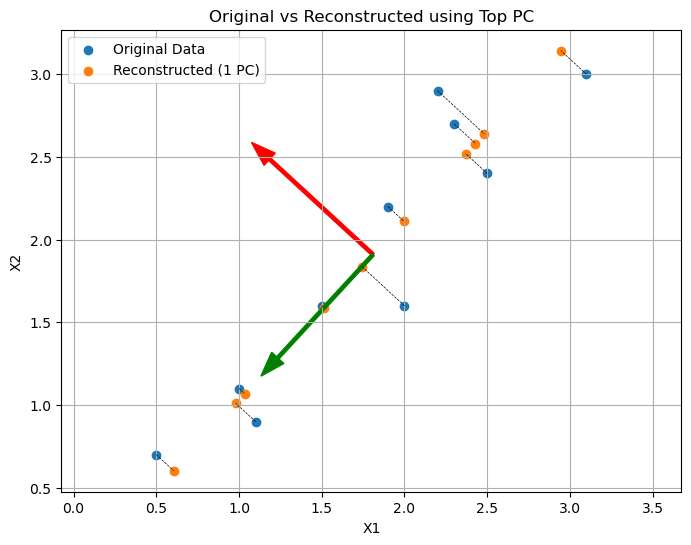

In [8]:
top_pc = eigvecs[:, np.argmax(eigvals)]
Z = centered_data @ top_pc
X_hat = np.outer(Z, top_pc) + mean_vec

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], label='Original Data')
plt.scatter(X_hat[:,0], X_hat[:,1], label='Reconstructed (1 PC)')
plt.legend()
plt.title("Original vs Reconstructed using Top PC")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.axis('equal')

# Add eigenvector arrows
origin = mean_vec
for i in range(2):
    vec = eigvecs[:, i]  # scale for visibility
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              color='red' if i == 0 else 'green', width=0.02, head_width=0.1, length_includes_head=True)

# Add lines between original and reconstructed points
for i in range(len(X)):
    plt.plot([X[i, 0], X_hat[i, 0]], [X[i, 1], X_hat[i, 1]], 'k--', linewidth=0.5)
plt.show()